<a href="https://colab.research.google.com/github/rajan-bhateja/Data-Analysis-with-Python/blob/main/Online_Retail_Store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline

In [58]:
warnings.filterwarnings('ignore')

In [59]:
df = pd.read_excel(r'/content/Online Retail.xlsx')

In [60]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


# Exploratory Data Analysis

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [62]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [63]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [64]:
df.duplicated().sum()

5268

In [65]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

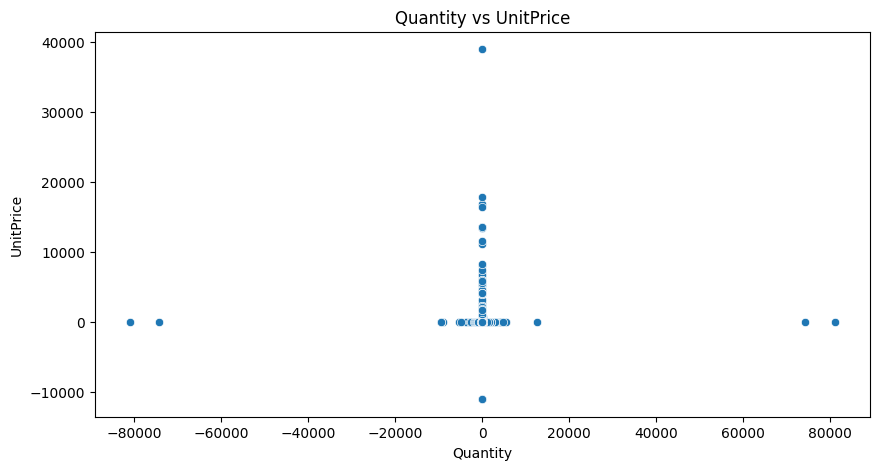

In [66]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Quantity',y='UnitPrice',data=df)
plt.title('Quantity vs UnitPrice')
plt.show()

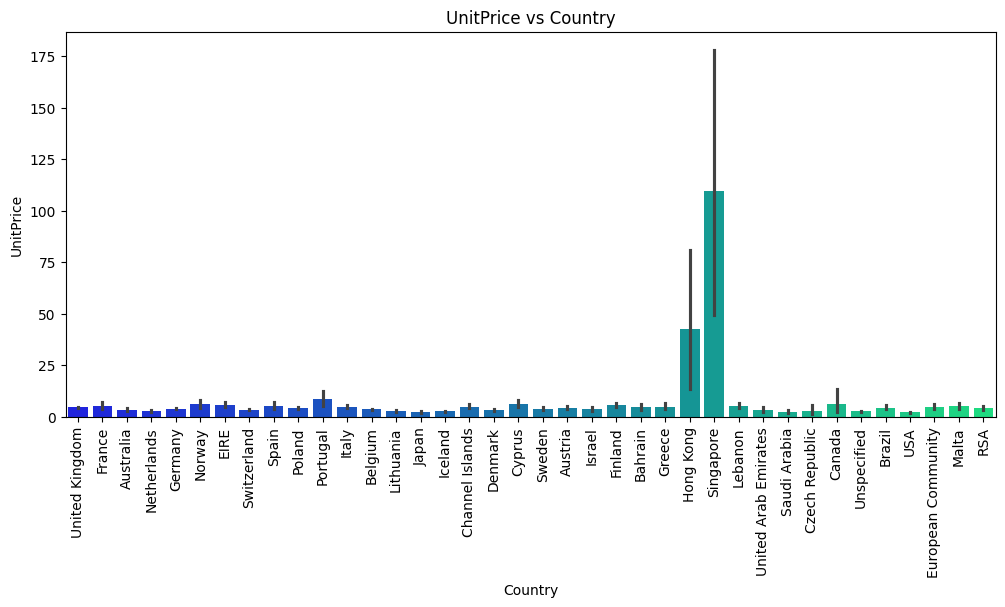

In [67]:
plt.figure(figsize=(12,5))
sns.barplot(x='Country',y='UnitPrice',data=df, hue='Country', palette='winter')
plt.title('UnitPrice vs Country')
plt.xticks(rotation=90)
plt.show()

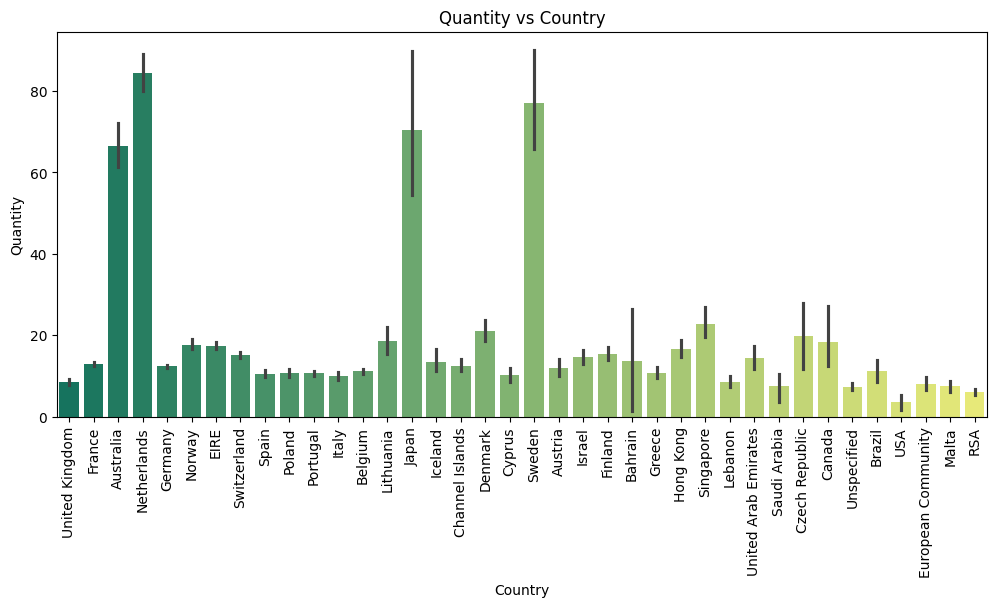

In [68]:
plt.figure(figsize=(12,5))
sns.barplot(x='Country',y='Quantity',data=df, hue='Country', palette='summer')
plt.title('Quantity vs Country')
plt.xticks(rotation=90)
plt.show()

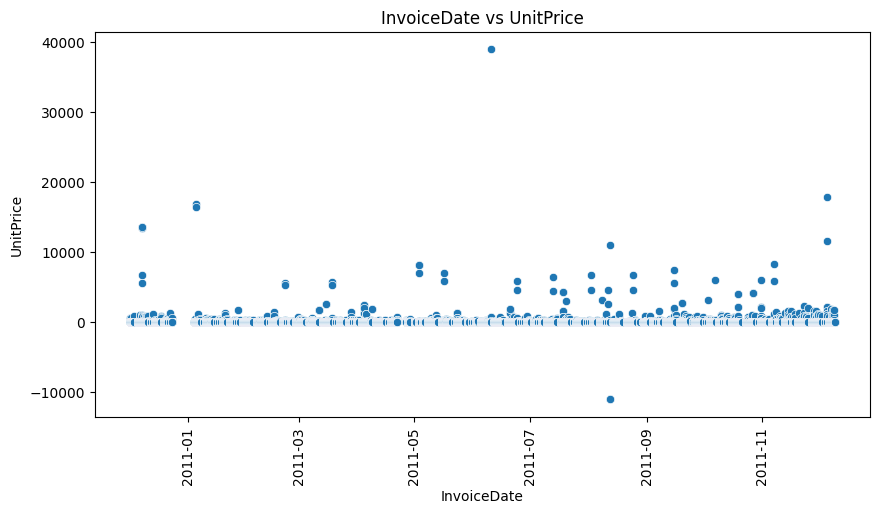

In [69]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='InvoiceDate', y='UnitPrice')
plt.title('InvoiceDate vs UnitPrice')
plt.xticks(rotation=90)
plt.show()

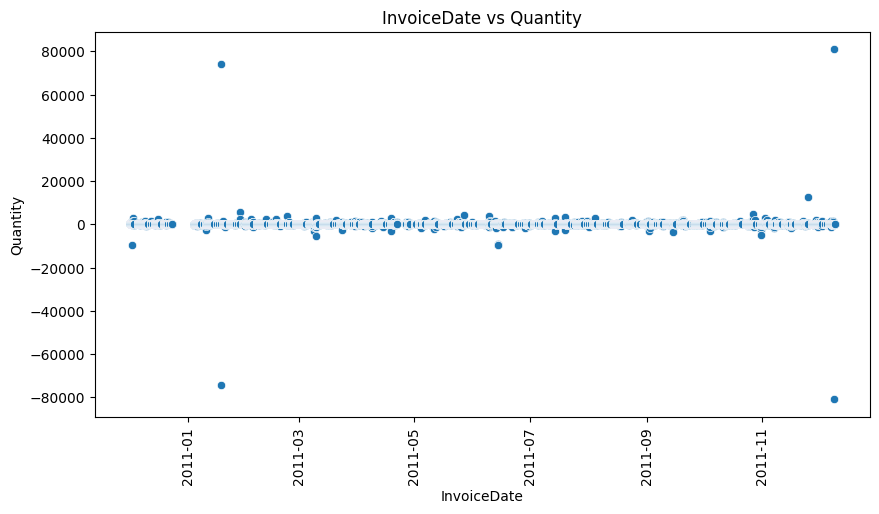

In [70]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='InvoiceDate', y='Quantity')
plt.title('InvoiceDate vs Quantity')
plt.xticks(rotation=90)
plt.show()

The following observations can be made about the data:
* There are 541909 records in the dataset
* There are **136534 missing values** and **5268 duplicates**
* The dataset requires a bit of cleaning, especially the `UnitPrice` and `Quantity` columns
* The `InvoiceDate` ranges from 1st December 2010 to 9th December 2011, so about a year's worth of data
* There are a few outliers in the dataset

# Data Cleaning and Preprocessing

In [71]:
# drop duplicates
df.drop_duplicates(inplace=True)

In [72]:
df.drop(columns=['StockCode','InvoiceNo', 'CustomerID'], inplace=True)

In [73]:
# removing negative values for Quantity and UnitPrice columns
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [74]:
# filtering the top 5% of the UnitPrice and Quantity
df = df[(df['Quantity'] < df['Quantity'].quantile(0.975)) & (df['UnitPrice'] < df['UnitPrice'].quantile(0.975))]

In [75]:
df.describe()

,Quantity,InvoiceDate,UnitPrice
count,489984.000000,489984,489984.000000
mean,6.485155,2011-07-05 05:14:05.283356416,2.915276
min,1.000000,2010-12-01 08:26:00,0.001000
25%,1.000000,2011-03-28 12:49:00,1.250000
50%,3.000000,2011-07-20 16:12:00,2.080000
75%,10.000000,2011-10-19 15:29:00,4.130000
max,47.000000,2011-12-09 12:50:00,12.720000
std,7.281877,NaN,2.445614


The dataset seems to be cleaned now.
*   The `Quantity` and `UnitPrice` columns have no outliers and their datapoints are in the correct range
*   `Year`, `Month`, `Day`, and `Hour` columns are all in their correct ranges
---



# Bit of Feature Engineering
* Extracting `Year`, `Month`, `Day`, and `Hour` from the `InvoiceDate` column
* Calculating the `Price` of the products (`UnitPrice` * `Quantity`)

In [76]:
# function to extract date time from datetime column
def extract_datetime(df):
  df['Year'] = df['InvoiceDate'].dt.year
  df['Month'] = df['InvoiceDate'].dt.month
  df['Day'] = df['InvoiceDate'].dt.day
  df['Hour'] = df['InvoiceDate'].dt.hour
  df.drop(columns='InvoiceDate', axis=1, inplace=True)
  # extracts the datetime features and removes the datetime column

In [77]:
extract_datetime(df)

In [78]:
df['TotalPrice'] = df['UnitPrice'] * df['Quantity']

In [79]:
df

,Description,Quantity,InvoiceDate,UnitPrice,Country,Year,Month,Day,Hour,TotalPrice
0,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,United Kingdom,2010,12,1,8,15.30
1,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,United Kingdom,2010,12,1,8,20.34
2,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,United Kingdom,2010,12,1,8,22.00
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,United Kingdom,2010,12,1,8,20.34
4,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,United Kingdom,2010,12,1,8,20.34
...,...,...,...,...,...,...,...,...,...,...
541904,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,France,2011,12,9,12,10.20
541905,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,France,2011,12,9,12,12.60
541906,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,France,2011,12,9,12,16.60
541907,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,France,2011,12,9,12,16.60


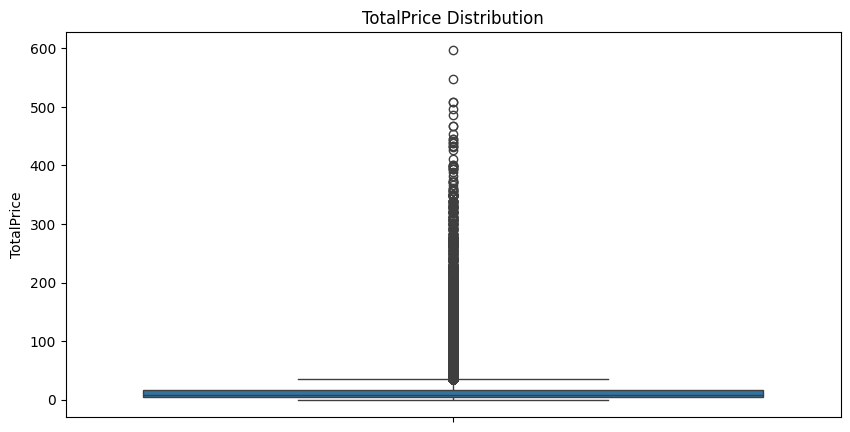

In [80]:
# show price distribution
plt.figure(figsize=(10,5))
sns.boxplot(data=df['TotalPrice'])
plt.title('TotalPrice Distribution')
plt.show()

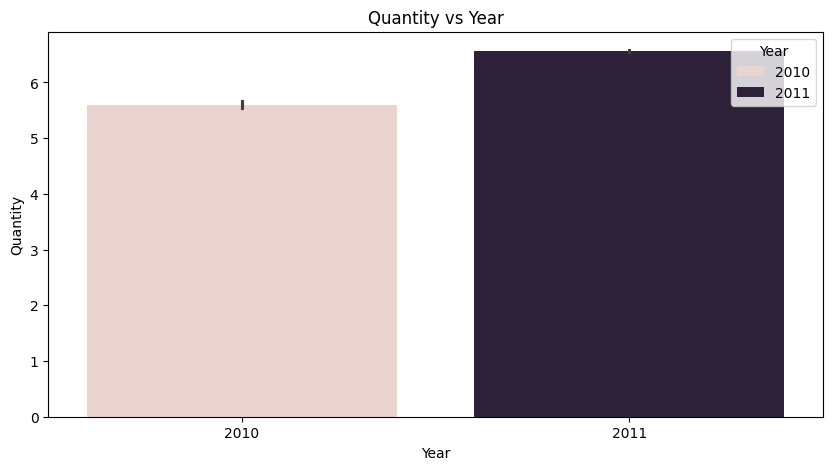

In [81]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='Year', y='Quantity', hue='Year')
plt.title('Quantity vs Year')
plt.show()

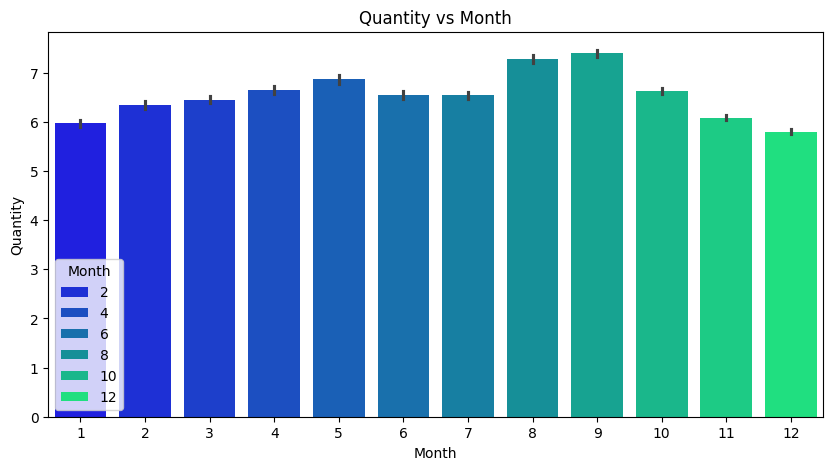

In [82]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='Month', y='Quantity', hue='Month', palette='winter')
plt.title('Quantity vs Month')
plt.show()

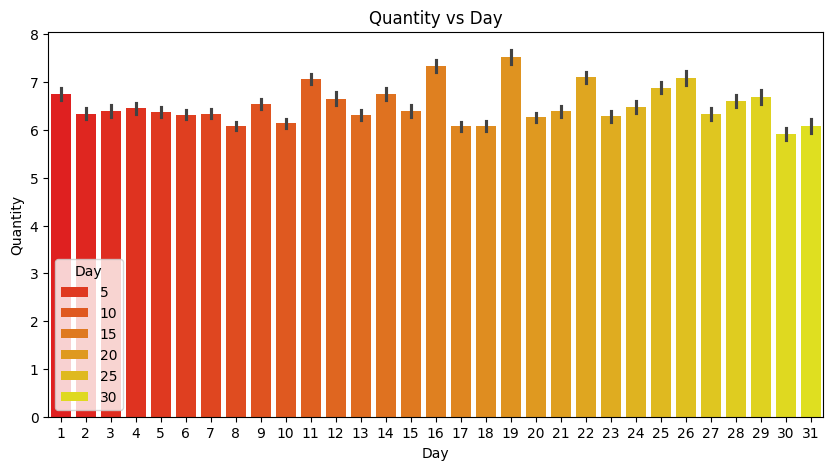

In [83]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='Day', y='Quantity', hue='Day', palette='autumn')
plt.title('Quantity vs Day')
plt.show()

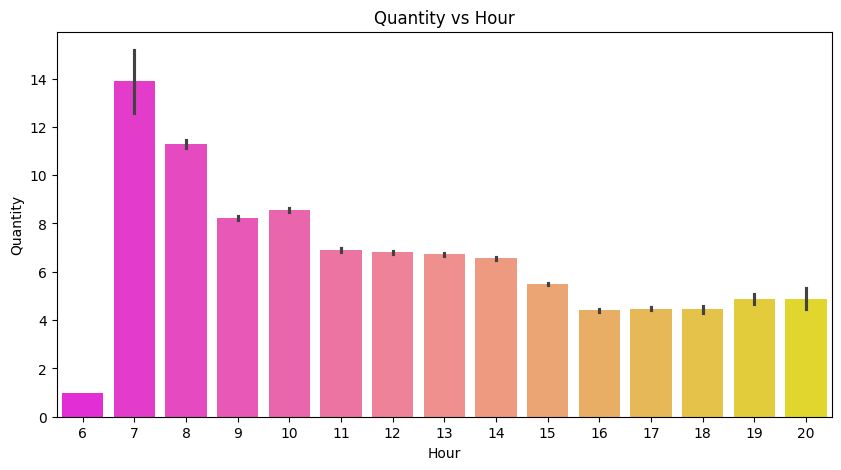

In [84]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='Hour', y='Quantity', palette='spring')
plt.title('Quantity vs Hour')
plt.show()

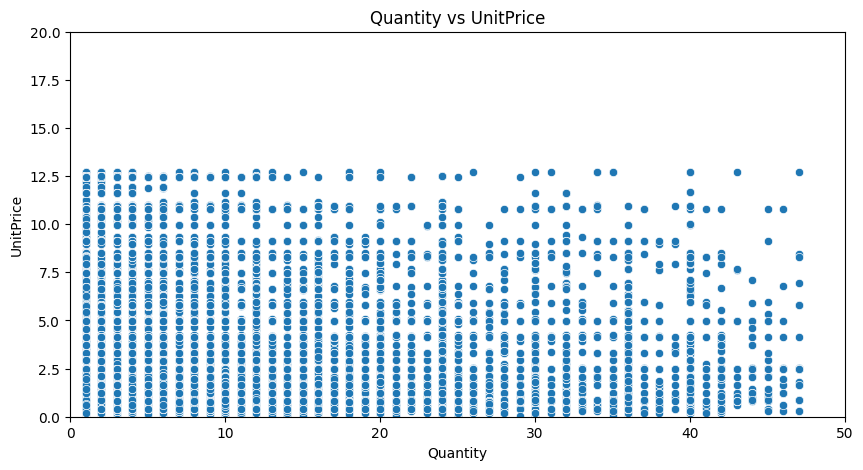

In [85]:
plt.figure(figsize=(10,5))
sns.scatterplot(df, x='Quantity', y='UnitPrice')
plt.title('Quantity vs UnitPrice')
plt.xlim(0, 50)
plt.ylim(0, 20)
plt.show()

In [97]:
# top 10 most expensive items
most_expensive_items = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
most_expensive_items

,TotalPrice
Description,
REGENCY CAKESTAND 3 TIER,60963.11
WHITE HANGING HEART T-LIGHT HOLDER,57316.63
PARTY BUNTING,52879.12
JUMBO BAG RED RETROSPOT,36619.56
PAPER CHAIN KIT 50'S CHRISTMAS,33828.29
ASSORTED COLOUR BIRD ORNAMENT,33016.02
SPOTTY BUNTING,30574.76
JAM MAKING SET WITH JARS,27948.05
CHOCOLATE HOT WATER BOTTLE,27457.88


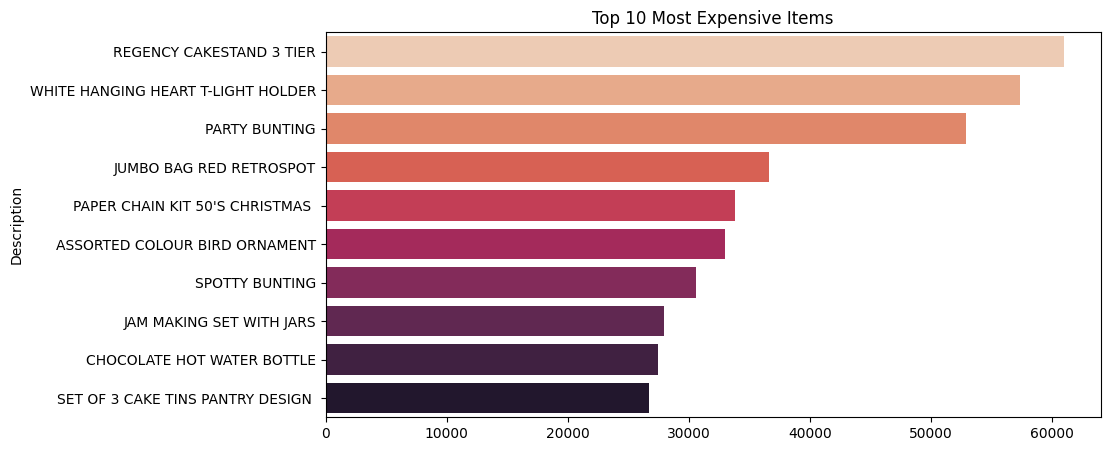

In [98]:
plt.figure(figsize=(10,5))
sns.barplot(y=most_expensive_items.index, x=most_expensive_items.values, palette='rocket_r')
plt.title('Top 10 Most Expensive Items')
plt.show()

In [87]:
# top 10 most selling items
top_selling_items = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_selling_items

,Quantity
Description,
WHITE HANGING HEART T-LIGHT HOLDER,19669
ASSORTED COLOUR BIRD ORNAMENT,19202
PACK OF 72 RETROSPOT CAKE CASES,17011
JUMBO BAG RED RETROSPOT,16157
LUNCH BAG RED RETROSPOT,12463
HEART OF WICKER SMALL,10775
PAPER CHAIN KIT 50'S CHRISTMAS,10767
VICTORIAN GLASS HANGING T-LIGHT,10418
JAM MAKING SET PRINTED,10042


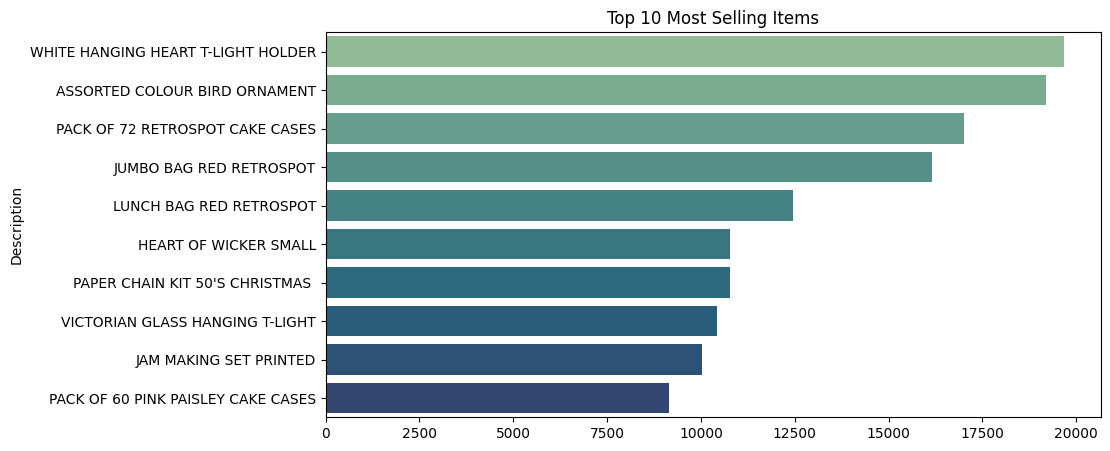

In [88]:
plt.figure(figsize=(10,5))
sns.barplot(y=top_selling_items.index, x=top_selling_items.values, palette='crest')
plt.title('Top 10 Most Selling Items')
plt.show()